In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from numpy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
trees = pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/biomass_model_dataset.csv")
species = pd.read_csv("/content/drive/MyDrive/DATA 311 Redwood Analytics/Project 3/FIATreeSpeciesCode.csv")

Mounted at /content/drive


In [3]:
trees.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM
0,12,7.5,45.2,178.86
1,12,9.3,62.7,323.46
2,12,9.7,56.7,342.47
3,12,11.4,66.1,499.35
4,12,6.4,51.8,113.92


In [ ]:
species.head()

,SPCD,COMMON_NAME,SCI_NAME,SPGRPCD.E,SPGRPCD.W,MAJGRP,OCC.NC,OCC.NE,OCC.PNW,OCC.RM,OCC.SO
0,10,fir spp.,Abies spp,6,12,2,X,X,-,-,X
1,11,Pacific silver fir,Abies amabilis,9,12,2,-,-,X,-,-
2,12,balsam fir,Abies balsamea,6,12,2,X,X,-,-,X
3,14,Santa Lucia or bristlecone fir,Abies bracteata,9,12,2,-,-,X,-,-
4,15,white fir,Abies concolor,9,12,2,X,-,X,X,X


In [4]:
species_codes = species[["SPCD","COMMON_NAME"]]
combined_df = trees.merge(species_codes,on='SPCD', how='left')
combined_df.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
0,12,7.5,45.2,178.86,balsam fir
1,12,9.3,62.7,323.46,balsam fir
2,12,9.7,56.7,342.47,balsam fir
3,12,11.4,66.1,499.35,balsam fir
4,12,6.4,51.8,113.92,balsam fir


In [27]:
sum(combined_df["COMMON_NAME"].isnull())

0

In [5]:
combined_df = combined_df.dropna(subset = "COMMON_NAME")

In [ ]:
#combined_df[combined_df['COMMON_NAME'].value_counts() > 30]=="True"


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [6]:
counts = combined_df["COMMON_NAME"].value_counts()
frequent_values = counts[counts >= 100].index
df_filtered = combined_df[combined_df["COMMON_NAME"].isin(frequent_values)]
df_filtered

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
0,12,7.5,45.2,178.86,balsam fir
1,12,9.3,62.7,323.46,balsam fir
2,12,9.7,56.7,342.47,balsam fir
3,12,11.4,66.1,499.35,balsam fir
4,12,6.4,51.8,113.92,balsam fir
...,...,...,...,...,...
137035,691,3.7,25.4,40.76,water tupelo
137036,691,3.2,28.8,28.44,water tupelo
137037,691,4.7,31.4,73.78,water tupelo
137038,691,4.4,26.9,62.64,water tupelo


In [7]:
df_filtered["COMMON_NAME"].value_counts()

,count
COMMON_NAME,
loblolly pine,20140
slash pine,8006
Douglas-fir,7322
ponderosa pine,5609
shortleaf pine,5599
...,...
sweet birch,135
sugarberry,120
pecan,120


In [8]:
train = []
test = []
selection = []
tree = []
for i in range(len(df_filtered)):
  #ntrain = df_filtered["COMMON_NAME"].value_counts()[0] * 0.80
  #nst = df_filtered["COMMON_NAME"].value_counts()[0] - ntrain
  #nselection = nst/2
  #ntest = nselection
  if (df_filtered["COMMON_NAME"].iloc[i] == "loblolly pine"):
    tree.append(df_filtered.iloc[i])
tree

[SPCD                     131
 DO_BH                    2.1
 HT_TOT                  14.3
 TT_DW_CRM               8.15
 COMMON_NAME    loblolly pine
 Name: 1312, dtype: object,
 SPCD                     131
 DO_BH                    2.9
 HT_TOT                  13.9
 TT_DW_CRM              17.75
 COMMON_NAME    loblolly pine
 Name: 1313, dtype: object,
 SPCD                     131
 DO_BH                    1.7
 HT_TOT                  11.5
 TT_DW_CRM               4.91
 COMMON_NAME    loblolly pine
 Name: 1314, dtype: object,
 SPCD                     131
 DO_BH                    1.9
 HT_TOT                  12.3
 TT_DW_CRM               6.41
 COMMON_NAME    loblolly pine
 Name: 1315, dtype: object,
 SPCD                     131
 DO_BH                    1.9
 HT_TOT                  12.2
 TT_DW_CRM               6.41
 COMMON_NAME    loblolly pine
 Name: 1316, dtype: object,
 SPCD                     131
 DO_BH                    3.0
 HT_TOT                  15.9
 TT_DW_CRM          

In [9]:
#make dataframe with certain common name
tree_loblolly = df_filtered.loc[df_filtered['COMMON_NAME'] == "loblolly pine"]

#find last index for tarining, test, and selection index
train_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.80)
test_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.90)
selection_index = int(tree["COMMON_NAME"].value_counts()[0])

#put in new dataframes
train = pd.DataFrame(tree.iloc[:train_index])
test = pd.DataFrame(tree.iloc[train_index:test_index])
selection = pd.DataFrame(tree.iloc[test_index:selection_index])

In [10]:
train

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
1312,131,2.1,14.3,8.15,loblolly pine
1313,131,2.9,13.9,17.75,loblolly pine
1314,131,1.7,11.5,4.91,loblolly pine
1315,131,1.9,12.3,6.41,loblolly pine
1316,131,1.9,12.2,6.41,loblolly pine
...,...,...,...,...,...
122287,131,10.4,72.2,669.67,loblolly pine
122288,131,13.1,70.5,1045.60,loblolly pine
122289,131,14.4,64.7,1165.20,loblolly pine
122290,131,4.8,29.6,60.16,loblolly pine


In [11]:
test

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
122292,131,5.1,20.7,20.74,loblolly pine
122293,131,7.0,27.6,98.93,loblolly pine
122294,131,6.1,32.9,85.09,loblolly pine
122295,131,6.4,33.0,97.21,loblolly pine
122296,131,7.2,36.5,147.37,loblolly pine
...,...,...,...,...,...
126027,131,6.5,50.5,167.28,loblolly pine
126028,131,3.9,39.6,36.36,loblolly pine
126029,131,6.7,46.0,161.52,loblolly pine
126030,131,4.6,35.6,54.26,loblolly pine


In [12]:
selection

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME
126032,131,5.0,27.5,34.15,loblolly pine
126033,131,5.4,44.2,89.64,loblolly pine
126034,131,2.2,16.7,9.11,loblolly pine
126035,131,3.0,23.3,19.26,loblolly pine
126036,131,7.2,63.1,269.50,loblolly pine
...,...,...,...,...,...
136966,131,9.7,57.2,460.06,loblolly pine
136967,131,9.3,55.3,407.37,loblolly pine
136968,131,9.1,67.3,474.54,loblolly pine
136969,131,11.0,77.3,803.18,loblolly pine


In [13]:
# Split data into training and testing sets
X_train = train[['DO_BH', 'HT_TOT']]
y_train = train['TT_DW_CRM']
X_test = test[['DO_BH', 'HT_TOT']]
y_test = test['TT_DW_CRM']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_scaled, y_train)
y_pred = knn_regressor.predict(X_test_scaled)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print(f"Root Mean Squared Log Error (RMSLE): {rmsle}")


Root Mean Squared Log Error (RMSLE): 0.03790264788899741


# Whole knn

In [15]:
df_filtered["COMMON_NAME"].value_counts().index[0]

'loblolly pine'

##Finding the best k value with average RMSLE values

In [16]:
for j in range(3,10):
  rmsle = []
  for i in range(len(df_filtered["COMMON_NAME"].value_counts())):
    tree_name = df_filtered["COMMON_NAME"].value_counts().index[i]

    #make dataframe with certain common name
    tree_subset = df_filtered.loc[df_filtered['COMMON_NAME'] == tree_name]

    #find last index for tarining, test, and selection index
    train_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.80)
    test_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.90)
    selection_index = int(tree["COMMON_NAME"].value_counts()[0])

    #put in new dataframes
    train = pd.DataFrame(tree.iloc[:train_index])
    test = pd.DataFrame(tree.iloc[train_index:test_index])
    selection = pd.DataFrame(tree.iloc[test_index:selection_index])

    # Split data into training and testing sets
    X_train = train[['DO_BH', 'HT_TOT']]
    y_train = train['TT_DW_CRM']
    X_test = test[['DO_BH', 'HT_TOT']]
    y_test = test['TT_DW_CRM']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_regressor = KNeighborsRegressor(n_neighbors=j)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred = knn_regressor.predict(X_test_scaled)

    rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #averages

  avg_rmsle = sum(rmsle)/len(rmsle) #averages
  print(f"Average Root Mean Squared Log Error (RMSLE) for k = {j}: {avg_rmsle}") #averages

Average Root Mean Squared Log Error (RMSLE) for k = 3: 0.15808192537990745
Average Root Mean Squared Log Error (RMSLE) for k = 4: 0.1621023466967089
Average Root Mean Squared Log Error (RMSLE) for k = 5: 0.16795249564678624
Average Root Mean Squared Log Error (RMSLE) for k = 6: 0.17425665440810242
Average Root Mean Squared Log Error (RMSLE) for k = 7: 0.18027567018264942
Average Root Mean Squared Log Error (RMSLE) for k = 8: 0.1850438023126977
Average Root Mean Squared Log Error (RMSLE) for k = 9: 0.19014856674351147


##Individual RMSLE values

In [17]:

rmsle = []
for i in range(len(df_filtered["COMMON_NAME"].value_counts())):
  tree_name = df_filtered["COMMON_NAME"].value_counts().index[i]
  #make dataframe with certain common name
  tree_subset = df_filtered.loc[df_filtered['COMMON_NAME'] == tree_name]
  #find last index for tarining, test, and selection index
  train_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.80)
  test_index = int(tree["COMMON_NAME"].value_counts()[0] * 0.90)
  selection_index = int(tree["COMMON_NAME"].value_counts()[0])

  #put in new dataframes
  train = pd.DataFrame(tree.iloc[:train_index])
  test = pd.DataFrame(tree.iloc[train_index:test_index])
  selection = pd.DataFrame(tree.iloc[test_index:selection_index])
  # Split data into training and testing sets
  X_train = train[['DO_BH', 'HT_TOT']]
  y_train = train['TT_DW_CRM']
  X_test = test[['DO_BH', 'HT_TOT']]
  y_test = test['TT_DW_CRM']

  # Scale the features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  knn_regressor = KNeighborsRegressor(n_neighbors=3)
  knn_regressor.fit(X_train_scaled, y_train)
  y_pred = knn_regressor.predict(X_test_scaled)
  rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #individual calculations

  print(f"Root Mean Squared Log Error (RMSLE) for {tree_name}: {rmsle[i]}") #individual calculations

Root Mean Squared Log Error (RMSLE) for loblolly pine: 0.04145372403582977
Root Mean Squared Log Error (RMSLE) for slash pine: 0.050144162239169975
Root Mean Squared Log Error (RMSLE) for Douglas-fir: 0.07990585373041438
Root Mean Squared Log Error (RMSLE) for ponderosa pine: 0.059678650639649077
Root Mean Squared Log Error (RMSLE) for shortleaf pine: 0.13556401643096178
Root Mean Squared Log Error (RMSLE) for longleaf pine: 0.038937162191602676
Root Mean Squared Log Error (RMSLE) for white oak: 0.12618266639905068
Root Mean Squared Log Error (RMSLE) for sweetgum: 0.03717647125522167
Root Mean Squared Log Error (RMSLE) for yellow-poplar: 0.07473531040938905
Root Mean Squared Log Error (RMSLE) for red maple: 0.10373950316242887
Root Mean Squared Log Error (RMSLE) for sugar maple: 0.22383817545061857
Root Mean Squared Log Error (RMSLE) for yellow birch: 0.19600560448128623
Root Mean Squared Log Error (RMSLE) for white fir : 0.15135119454355578
Root Mean Squared Log Error (RMSLE) for quak

(array([11., 13.,  8., 12., 13.,  9.,  1., 10.,  5.,  3.,  2.,  1.,  2.,
         3.,  2.,  1.,  0.,  1.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([0.03717647, 0.05815402, 0.07913157, 0.10010911, 0.12108666,
        0.14206421, 0.16304176, 0.1840193 , 0.20499685, 0.2259744 ,
        0.24695195, 0.26792949, 0.28890704, 0.30988459, 0.33086214,
        0.35183968, 0.37281723, 0.39379478, 0.41477233, 0.43574987,
        0.45672742, 0.47770497, 0.49868252, 0.51966006, 0.54063761,
        0.56161516, 0.5825927 , 0.60357025, 0.6245478 , 0.64552535,
        0.66650289]),
 <BarContainer object of 30 artists>)

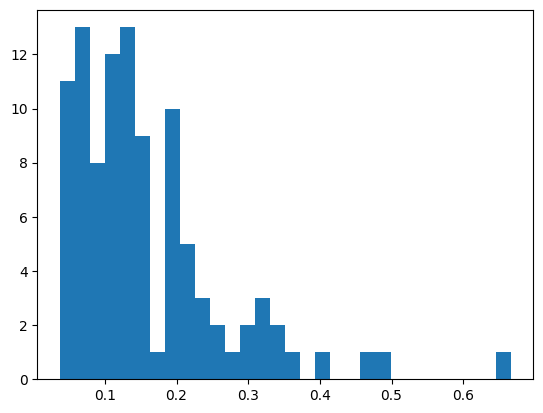

In [18]:
plt.hist(rmsle, bins=30)

# Using volume of cylinder interaction

In [30]:
tree_w_cylinder = df_filtered.assign(VOLUME = (df_filtered["HT_TOT"]*3.14159*(0.5*df_filtered["DO_BH"])**2))
tree_w_cylinder.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME,VOLUME
0,12,7.5,45.2,178.86,balsam fir,1996.873144
1,12,9.3,62.7,323.46,balsam fir,4259.150167
2,12,9.7,56.7,342.47,balsam fir,4190.019479
3,12,11.4,66.1,499.35,balsam fir,6746.844127
4,12,6.4,51.8,113.92,balsam fir,1666.399867


In [32]:
for j in range(3,10):
  rmsle = []
  for i in range(len(tree_w_cylinder["COMMON_NAME"].value_counts())):
    tree_name = tree_w_cylinder["COMMON_NAME"].value_counts().index[i]

    #make dataframe with certain common name
    tree_subset = tree_w_cylinder.loc[tree_w_cylinder['COMMON_NAME'] == tree_name]

    #find last index for tarining, test, and selection index
    train_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.80)
    test_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.90)
    selection_index = int(tree_subset["COMMON_NAME"].value_counts()[0])

    #put in new dataframes
    train = pd.DataFrame(tree_subset.iloc[:train_index])
    test = pd.DataFrame(tree_subset.iloc[train_index:test_index])
    selection = pd.DataFrame(tree_subset.iloc[test_index:selection_index])

    # Split data into training and testing sets
    X_train = train[['DO_BH', 'HT_TOT', 'VOLUME']]
    y_train = train['TT_DW_CRM']
    X_test = test[['DO_BH', 'HT_TOT', 'VOLUME']]
    y_test = test['TT_DW_CRM']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_regressor = KNeighborsRegressor(n_neighbors=j)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred = knn_regressor.predict(X_test_scaled)

    rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #averages

  avg_rmsle = sum(rmsle)/len(rmsle) #averages
  print(f"Average Root Mean Squared Log Error (RMSLE) for k = {j}: {avg_rmsle}") #averages

Average Root Mean Squared Log Error (RMSLE) for k = 3: 0.15544459921264525
Average Root Mean Squared Log Error (RMSLE) for k = 4: 0.1598134725681196
Average Root Mean Squared Log Error (RMSLE) for k = 5: 0.16579173029566077
Average Root Mean Squared Log Error (RMSLE) for k = 6: 0.1710919547848324
Average Root Mean Squared Log Error (RMSLE) for k = 7: 0.1781729708531949
Average Root Mean Squared Log Error (RMSLE) for k = 8: 0.18325514917808453
Average Root Mean Squared Log Error (RMSLE) for k = 9: 0.18865741683935117


In [43]:
tree_height_int = df_filtered.assign(H_SQUARED = (df_filtered["HT_TOT"]**2))
tree_height_int.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME,H_SQUARED
0,12,7.5,45.2,178.86,balsam fir,2043.04
1,12,9.3,62.7,323.46,balsam fir,3931.29
2,12,9.7,56.7,342.47,balsam fir,3214.89
3,12,11.4,66.1,499.35,balsam fir,4369.21
4,12,6.4,51.8,113.92,balsam fir,2683.24


In [38]:
for j in range(3,10):
  rmsle = []
  for i in range(len(tree_height_int["COMMON_NAME"].value_counts())):
    tree_name = tree_height_int["COMMON_NAME"].value_counts().index[i]

    #make dataframe with certain common name
    tree_subset = tree_height_int.loc[tree_height_int['COMMON_NAME'] == tree_name]

    #find last index for tarining, test, and selection index
    train_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.80)
    test_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.90)
    selection_index = int(tree_subset["COMMON_NAME"].value_counts()[0])

    #put in new dataframes
    train = pd.DataFrame(tree_subset.iloc[:train_index])
    test = pd.DataFrame(tree_subset.iloc[train_index:test_index])
    selection = pd.DataFrame(tree_subset.iloc[test_index:selection_index])

    # Split data into training and testing sets
    X_train = train[['DO_BH', 'HT_TOT', 'H_SQUARED']]
    y_train = train['TT_DW_CRM']
    X_test = test[['DO_BH', 'HT_TOT', 'H_SQUARED']]
    y_test = test['TT_DW_CRM']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_regressor = KNeighborsRegressor(n_neighbors=j)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred = knn_regressor.predict(X_test_scaled)

    rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #averages

  avg_rmsle = sum(rmsle)/len(rmsle) #averages
  print(f"Average Root Mean Squared Log Error (RMSLE) for k = {j}: {avg_rmsle}") #averages

Average Root Mean Squared Log Error (RMSLE) for k = 3: 0.1718113698793754
Average Root Mean Squared Log Error (RMSLE) for k = 4: 0.17708551556594312
Average Root Mean Squared Log Error (RMSLE) for k = 5: 0.1855075481075846
Average Root Mean Squared Log Error (RMSLE) for k = 6: 0.1934297649882555
Average Root Mean Squared Log Error (RMSLE) for k = 7: 0.19980394201965201
Average Root Mean Squared Log Error (RMSLE) for k = 8: 0.20586996936821803
Average Root Mean Squared Log Error (RMSLE) for k = 9: 0.21140748056270467


In [40]:
tree_h_w_int = df_filtered.assign(H_D_INT = (df_filtered["HT_TOT"]*df_filtered["DO_BH"]))
tree_h_w_int.head()

,SPCD,DO_BH,HT_TOT,TT_DW_CRM,COMMON_NAME,H_D_INT
0,12,7.5,45.2,178.86,balsam fir,339.00
1,12,9.3,62.7,323.46,balsam fir,583.11
2,12,9.7,56.7,342.47,balsam fir,549.99
3,12,11.4,66.1,499.35,balsam fir,753.54
4,12,6.4,51.8,113.92,balsam fir,331.52


In [41]:
for j in range(3,10):
  rmsle = []
  for i in range(len(tree_h_w_int["COMMON_NAME"].value_counts())):
    tree_name = tree_h_w_int["COMMON_NAME"].value_counts().index[i]

    #make dataframe with certain common name
    tree_subset = tree_h_w_int.loc[tree_h_w_int['COMMON_NAME'] == tree_name]

    #find last index for tarining, test, and selection index
    train_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.80)
    test_index = int(tree_subset["COMMON_NAME"].value_counts()[0] * 0.90)
    selection_index = int(tree_subset["COMMON_NAME"].value_counts()[0])

    #put in new dataframes
    train = pd.DataFrame(tree_subset.iloc[:train_index])
    test = pd.DataFrame(tree_subset.iloc[train_index:test_index])
    selection = pd.DataFrame(tree_subset.iloc[test_index:selection_index])

    # Split data into training and testing sets
    X_train = train[['DO_BH', 'HT_TOT', 'H_D_INT']]
    y_train = train['TT_DW_CRM']
    X_test = test[['DO_BH', 'HT_TOT', 'H_D_INT']]
    y_test = test['TT_DW_CRM']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    knn_regressor = KNeighborsRegressor(n_neighbors=j)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred = knn_regressor.predict(X_test_scaled)

    rmsle.append(np.sqrt(mean_squared_log_error(y_test, y_pred))) #averages

  avg_rmsle = sum(rmsle)/len(rmsle) #averages
  print(f"Average Root Mean Squared Log Error (RMSLE) for k = {j}: {avg_rmsle}") #averages

Average Root Mean Squared Log Error (RMSLE) for k = 3: 0.15623498401770455
Average Root Mean Squared Log Error (RMSLE) for k = 4: 0.15975698611425826
Average Root Mean Squared Log Error (RMSLE) for k = 5: 0.16553398882187495
Average Root Mean Squared Log Error (RMSLE) for k = 6: 0.17199361415007658
Average Root Mean Squared Log Error (RMSLE) for k = 7: 0.17700695960552104
Average Root Mean Squared Log Error (RMSLE) for k = 8: 0.18258821333564118
Average Root Mean Squared Log Error (RMSLE) for k = 9: 0.18817309695761697
